<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center"><b>S H A G G Y   —   G R A P H   A U T O E N C O D E R</b></p>
<hr style="color:#808080;">

A demonstration of **GraphAE** (`shaggy.models.gae`) on real data: sea temperature
in the Black Sea, at 2 vertical levels, on a 256 x 576 lat/lon grid. Land cells are
masked out (NaN); `shaggy.tools.build_mesh` builds the mesh directly over the sea
cells only, so no compute or latent capacity is wasted on land.

Steps: load the data and build the mesh &rarr; create and train the GraphAE &rarr;
evaluate reconstruction quality (RMSE) against a naive baseline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from IPython.display import clear_output

from shaggy.loss import AELoss
from shaggy.models.gae import create_GraphAE
from shaggy.optimizer import SOAP
from shaggy.tools import build_mesh

# This machine exposes a lot of CPU cores (shared HPC node); torch's default of
# spawning that many threads for tiny per-node tensor ops is pure overhead here
# and makes the graph ops ~100x slower than they need to be. A handful is plenty.
torch.set_num_threads(4)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

<hr style="color:#808080;">
<p align="center"><b>D A T A   &amp;   M E S H</b></p>
<hr style="color:#808080;">

In [2]:
x = torch.load("data/black-sea/x.pt")        # (B, C, X, Y), NaN on land
mask = torch.load("data/black-sea/mask.pt")  # (C, X, Y), 1 = sea, 0 = land

B, C, X, Y = x.shape
print(f"x    : {tuple(x.shape)}  ({B} samples, {C} vertical levels, {X}x{Y} grid)")
print(f"mask : {tuple(mask.shape)}")

# Level 1 (deeper) only has data where level 0 (shallower) also does, so level 0's
# mask is the superset: it defines which grid cells exist as nodes at all. Cells
# that are sea at level 0 but land at level 1 (e.g. shallow coastal water) are kept
# as nodes and simply filled with 0 for that one channel (see AELoss weights below).
domain_mask = mask[0] > 0.5
print(f"sea cells: {domain_mask.sum().item()} / {domain_mask.numel()} ({100 * domain_mask.float().mean().item():.1f}%)")

x_filled = torch.nan_to_num(x, nan=0.0).to(device)
weights = mask.unsqueeze(0).to(device)  # (1, C, X, Y), broadcasts over the batch

x    : (4, 2, 256, 576)  (4 samples, 2 vertical levels, 256x576 grid)
mask : (2, 256, 576)
sea cells: 74056 / 147456 (50.2%)


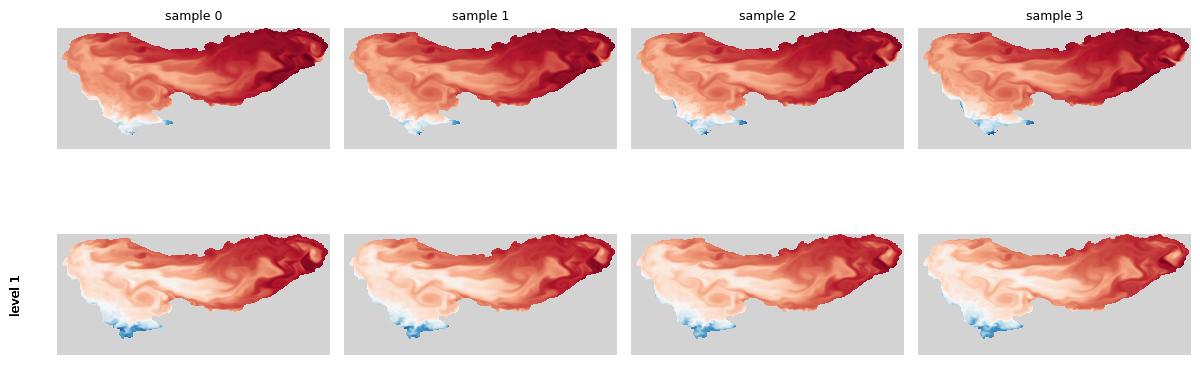

In [3]:
def show_fields(fields, mask, titles=None, cmap="RdBu_r"):
    r'''Displays a (N, C, X, Y) tensor, one row per channel, land cells left blank.'''
    fields = fields.detach().cpu().numpy()
    mask = mask.detach().cpu().numpy()
    n, c = fields.shape[:2]

    cmap = plt.get_cmap(cmap).copy()
    cmap.set_bad("lightgray")

    fig, axes = plt.subplots(c, n, figsize=(3 * n, 2.6 * c), squeeze=False)

    for j in range(n):
        for i in range(c):
            level_mask = mask[i] if mask.ndim == 3 else mask[0, i]
            field = np.ma.masked_where(level_mask < 0.5, fields[j, i])
            axes[i, j].imshow(field, cmap=cmap)
            axes[i, j].axis("off")
            if titles is not None and i == 0:
                axes[i, j].set_title(titles[j], fontsize=9)
        axes[i, 0].text(-0.15, 0.5, f"level {i}", transform=axes[i, 0].transAxes,
                         rotation=90, va="center", ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()


show_fields(x_filled, mask, titles=[f"sample {i}" for i in range(B)])

In [4]:
mesh = build_mesh(
    resolution=(X, Y),
    num_levels=4,
    reduction=4,
    k=8,
    iterations=8,
    mask=domain_mask,
    seed=0,
)

for level, pos in enumerate(mesh.pos):
    tag = "grid (sea cells)" if level == 0 else f"mesh level {level}"
    print(f"Level {level} ({tag:<16}): {pos.shape[0]:6d} nodes")

Level 0 (grid (sea cells)):  74056 nodes
Level 1 (mesh level 1    ):  18514 nodes
Level 2 (mesh level 2    ):   4628 nodes
Level 3 (mesh level 3    ):   1157 nodes
Level 4 (mesh level 4    ):    289 nodes


<hr style="color:#808080;">
<p align="center"><b>M E S H   L E V E L S</b></p>
<hr style="color:#808080;">

Each level's nodes plotted directly over the domain, to see how the K-means
hierarchy follows the Black Sea's geometry — denser where the coastline is
irregular, coarser offshore. Level 0 has one node per sea pixel (74056 of
them), so it is shown as the mask itself rather than as individual points.

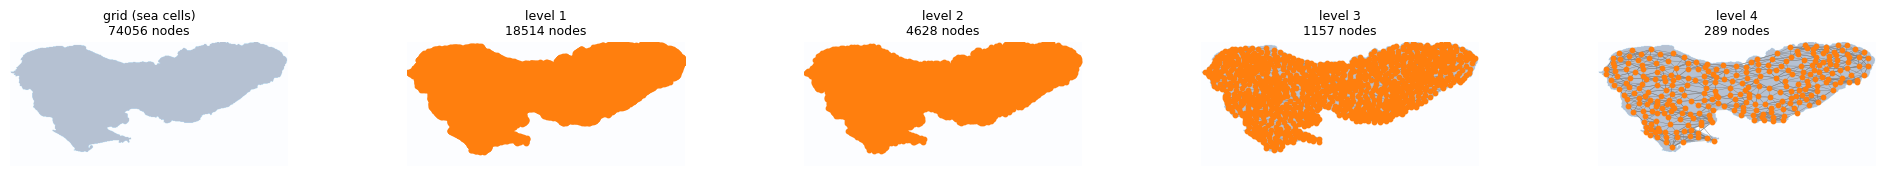

In [5]:
def _mesh_panel(ax, level, pos, edges, mask, title, max_edges=1500):
    r'''Draws one mesh level's nodes/edges over the domain onto a given axis.'''
    domain = (mask[0] if mask.dim() == 3 else mask).cpu().numpy()
    X, Y = domain.shape

    ax.imshow(domain, cmap="Blues", alpha=0.3)
    ax.axis("off")
    ax.set_title(title, fontsize=9)

    if level == 0:
        return  # one node per sea pixel: the mask above already shows them all

    rows, cols = pos[:, 0].numpy() * (X - 1), pos[:, 1].numpy() * (Y - 1)

    e = edges
    if e.shape[1] > max_edges:
        idx = torch.randperm(e.shape[1])[:max_edges]
        e = e[:, idx]
    for src, dst in e.T:
        ax.plot([cols[src], cols[dst]], [rows[src], rows[dst]], color="gray", linewidth=0.3, zorder=1)

    ax.scatter(cols, rows, s=10, zorder=2, color="C1")


def plot_mesh_geo(mesh, mask):
    r'''Plots every mesh level's nodes/edges over the domain, side by side.'''
    fig, axes = plt.subplots(1, len(mesh.pos), figsize=(4 * len(mesh.pos), 4 * X / Y))

    for level, (ax, pos, edges) in enumerate(zip(axes, mesh.pos, mesh.edges)):
        tag = "grid (sea cells)" if level == 0 else f"level {level}"
        _mesh_panel(ax, level, pos, edges, mask, f"{tag}\n{pos.shape[0]} nodes")

    plt.tight_layout()
    plt.show()


plot_mesh_geo(mesh, mask)

<hr style="color:#808080;">
<p align="center"><b>M O D E L</b></p>
<hr style="color:#808080;">

In [10]:
config = {
    "in_channels": C,
    "out_channels": C,
    "lat_channels": 16,
    "hid_channels": [16, 32, 64, 128],
    "hid_blocks": [8, 8, 8, 8],
    "saturation": "softclip2",
    "saturation_bound": 5.0,
}

model = create_GraphAE(**config, mesh=mesh).to(device)

n_params = sum(p.numel() for p in model.parameters())
lat_nodes, lat_channels = model.latent_shape()
_, factor = model.compression_info((C, X, Y))

print(f"Parameters   : {n_params:,}")
print(f"Latent shape : ({lat_nodes} nodes, {lat_channels} channels)")
print(f"Compression  : x{factor}")

Parameters   : 2,179,544
Latent shape : (289 nodes, 16 channels)
Compression  : x63


<hr style="color:#808080;">
<p align="center"><b>T H E   G R A P H   T H R O U G H   T H E   G A E</b></p>
<hr style="color:#808080;">

The encoder and decoder reuse the exact same mesh, just traversed in opposite
directions: the encoder pools grid &rarr; level 1 &rarr; ... &rarr; level L
(channels growing towards the latent size), the decoder unpools level L
&rarr; ... &rarr; level 1 &rarr; grid (channels shrinking back down).

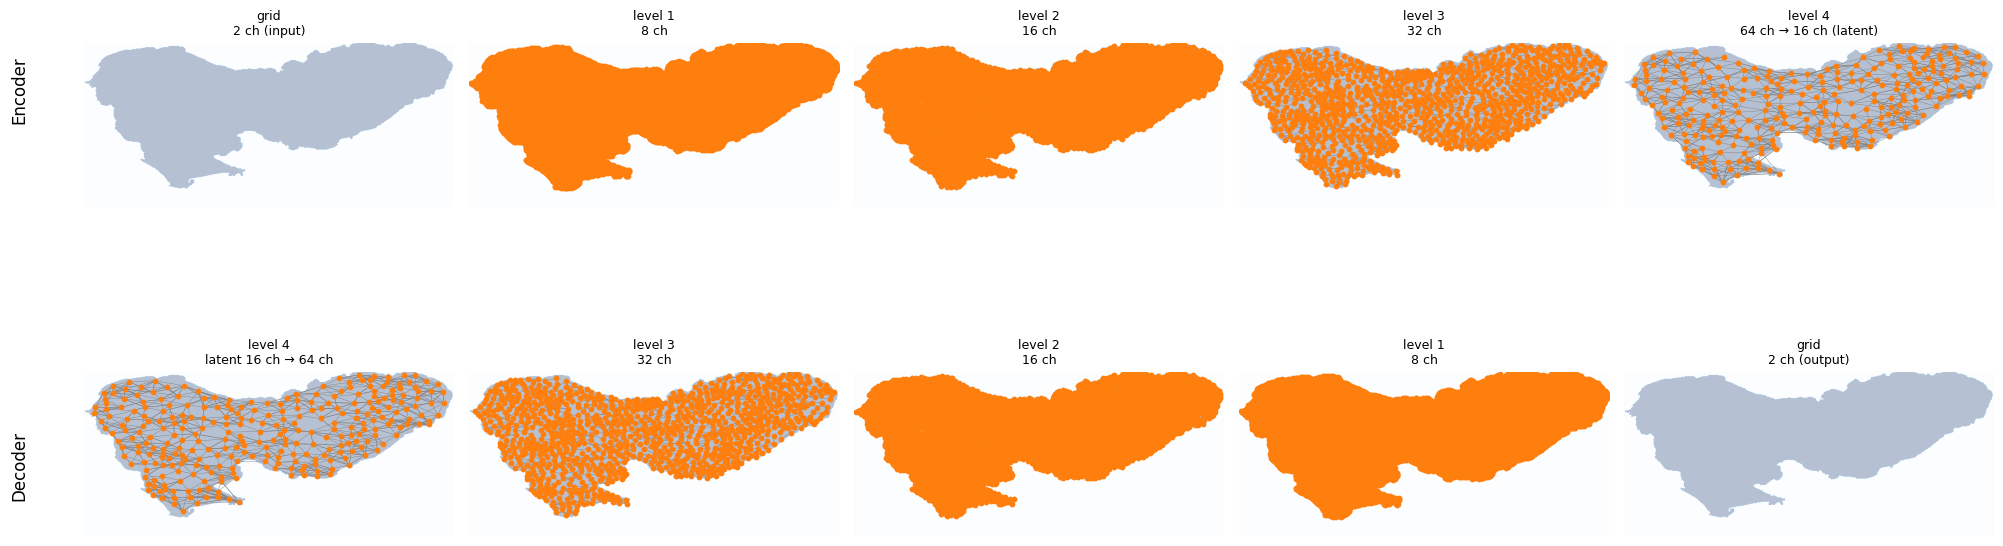

In [7]:
hid = config["hid_channels"]
L = mesh.num_levels

encoder_titles = []
for level in range(L + 1):
    if level == 0:
        encoder_titles.append(f"grid\n{config['in_channels']} ch (input)")
    elif level == L:
        encoder_titles.append(f"level {level}\n{hid[level - 1]} ch → {config['lat_channels']} ch (latent)")
    else:
        encoder_titles.append(f"level {level}\n{hid[level - 1]} ch")

decoder_titles = []
for level in range(L, -1, -1):
    if level == L:
        decoder_titles.append(f"level {level}\nlatent {config['lat_channels']} ch → {hid[level - 1]} ch")
    elif level == 0:
        decoder_titles.append(f"grid\n{config['out_channels']} ch (output)")
    else:
        decoder_titles.append(f"level {level}\n{hid[level - 1]} ch")

fig, axes = plt.subplots(2, L + 1, figsize=(4 * (L + 1), 8))

for j, level in enumerate(range(L + 1)):
    _mesh_panel(axes[0, j], level, mesh.pos[level], mesh.edges[level], mask, encoder_titles[j])

for j, level in enumerate(range(L, -1, -1)):
    _mesh_panel(axes[1, j], level, mesh.pos[level], mesh.edges[level], mask, decoder_titles[j])

fig.text(0.005, 0.75, "Encoder", va="center", ha="center", fontsize=12, rotation=90)
fig.text(0.005, 0.28, "Decoder", va="center", ha="center", fontsize=12, rotation=90)

plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.show()

<hr style="color:#808080;">
<p align="center"><b>T R A I N I N G</b></p>
<hr style="color:#808080;">

Only 4 samples are available, so this trains on (and is evaluated on) the same 4
fields — a reconstruction/memorization check on real data rather than a
generalization benchmark. `AELoss` is weighted by the sea mask so that land cells
(filled with 0 above) never contribute to the loss.

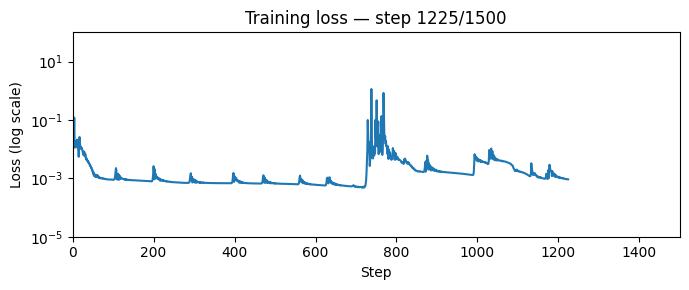

In [ ]:
config_training = {
    "lr": 5e-3,
    "steps": 1500,
}

loss_fn = AELoss(weights=weights).to(device)
optimizer = SOAP(model.parameters(), lr=config_training["lr"])

losses = []

for step in range(1, config_training["steps"] + 1):
    _, x_hat = model(x_filled)
    loss = loss_fn(x_hat, x_filled)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if step % 25 == 0 or step == config_training["steps"]:
        clear_output(wait=True)

        fig, ax = plt.subplots(figsize=(7, 3))
        ax.plot(losses, linewidth=1.5)
        ax.set_yscale("log")
        ax.set_ylim(bottom=1e-5, top=1e2)
        ax.set_xlim(left=0, right=config_training["steps"])
        ax.set_xlabel("Step")
        ax.set_ylabel("Loss (log scale)")
        ax.set_title(f"Training loss — step {step}/{config_training['steps']}")
        plt.tight_layout()
        plt.show()

<hr style="color:#808080;">
<p align="center"><b>E V A L U A T I O N</b></p>
<hr style="color:#808080;">

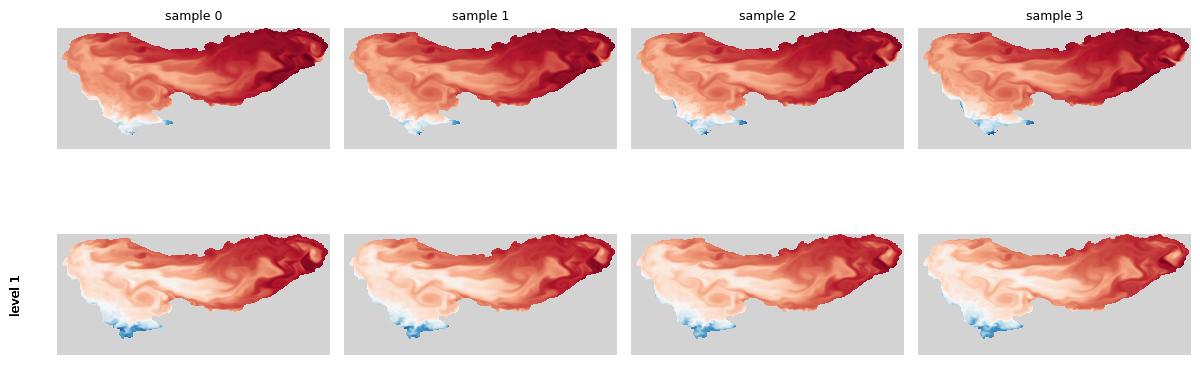

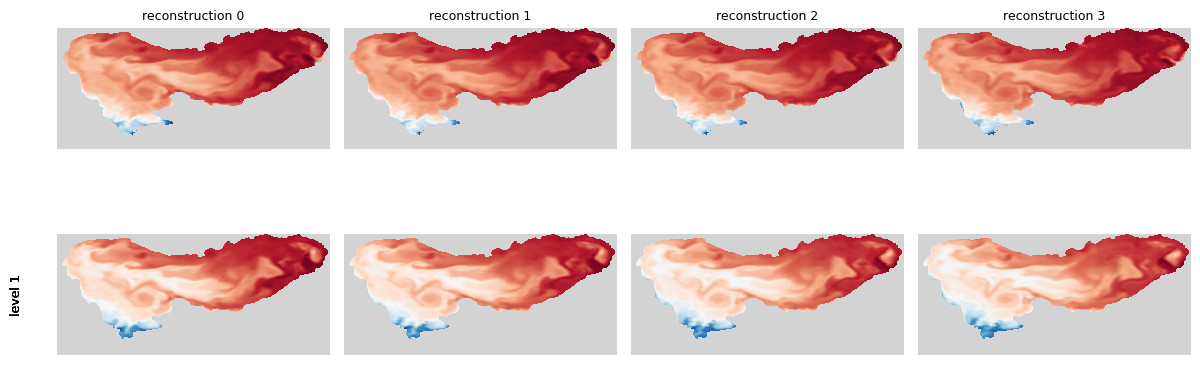

In [9]:
model.eval()

with torch.no_grad():
    _, reconstructions = model(x_filled)

show_fields(x_filled, mask, titles=[f"sample {i}" for i in range(B)])
show_fields(reconstructions, mask, titles=[f"reconstruction {i}" for i in range(B)])

In [ ]:
def rmse_per_sample(a, b, weights):
    r'''Sea-only RMSE per sample, ignoring land cells.'''
    error2 = (a - b) ** 2 * weights
    return torch.sqrt(error2.sum(dim=(1, 2, 3)) / weights.sum(dim=(1, 2, 3)).clamp(min=1))


rmse_model = rmse_per_sample(reconstructions, x_filled, weights)

# Naive baseline: predicting the mean of the 4 samples for every sample.
baseline = x_filled.mean(dim=0, keepdim=True)
rmse_baseline = rmse_per_sample(baseline, x_filled, weights)

print("Sample   GraphAE RMSE   Mean-baseline RMSE")
for i in range(B):
    print(f"{i:^6d}   {rmse_model[i].item():^13.4f}   {rmse_baseline[i].item():^19.4f}")

print(f"\nMean     {rmse_model.mean().item():^13.4f}   {rmse_baseline.mean().item():^19.4f}")